In [ ]:
!pip install gala
!pip install astroquery

In [2]:
from astropy.coordinates import SkyCoord
from astropy import units as u
import astropy_xarray.coordinates
from astroquery.gaia import Gaia

In [3]:
from gala.coordinates import GD1Koposov10

gd1_frame = GD1Koposov10()
gd1_frame

<GD1Koposov10 Frame>

In [4]:
phi1_min = -55 * u.degree
phi1_max = -45 * u.degree
phi2_min = -8 * u.degree
phi2_max = 4 * u.degree

def make_rectangle(x1, x2, y1, y2):
    """Return the corners of a rectangle."""
    xs = [x1, x1, x2, x2, x1]
    ys = [y1, y2, y2, y1, y1]
    return xs, ys

phi1_rect, phi2_rect = make_rectangle(
    phi1_min, phi1_max, phi2_min, phi2_max
)

corners = SkyCoord(phi1=phi1_rect, phi2=phi2_rect, frame=gd1_frame)

corners_icrs = corners.transform_to('icrs')
corners_icrs


<SkyCoord (ICRS): (ra, dec) in deg
    [(146.27533314, 19.26190982), (135.42163944, 25.87738723),
     (141.60264825, 34.3048303 ), (152.81671045, 27.13611254),
     (146.27533314, 19.26190982)]>

In [5]:
def skycoord_to_adql(skycoord):
    """Convert a one-dimensional list of SkyCoord to string for Gaia's query format."""
    corners_list_str = skycoord.to_string()
    corners_single_str = ' '.join(corners_list_str)
    return corners_single_str.replace(' ', ', ')

sky_points = skycoord_to_adql(corners_icrs)
sky_points

'146.275, 19.2619, 135.422, 25.8774, 141.603, 34.3048, 152.817, 27.1361, 146.275, 19.2619'

In [6]:
columns = 'source_id, ra, dec, pmra, pmdec, parallax'
polygon_query_template = """SELECT
{columns}
FROM gaiadr2.gaia_source
WHERE parallax < 1
  AND bp_rp BETWEEN -0.75 AND 2
  AND 1 = CONTAINS(
    POINT(ra, dec),
    POLYGON({sky_points})
  )
"""

polygon_query = polygon_query_template.format(
    columns=columns,
    sky_points=sky_points
)
print(polygon_query)

SELECT
source_id, ra, dec, pmra, pmdec, parallax
FROM gaiadr2.gaia_source
WHERE parallax < 1
  AND bp_rp BETWEEN -0.75 AND 2
  AND 1 = CONTAINS(
    POINT(ra, dec),
    POLYGON(146.275, 19.2619, 135.422, 25.8774, 141.603, 34.3048, 152.817, 27.1361, 146.275, 19.2619)
  )



In [6]:
polygon_query_job = Gaia.launch_job_async(polygon_query)
print(polygon_query_job)

INFO: Query finished. [astroquery.utils.tap.core]
<Table length=140339>
   name    dtype    unit                              description                            
--------- ------- -------- ------------------------------------------------------------------
source_id   int64          Unique source identifier (unique within a particular Data Release)
       ra float64      deg                                                    Right ascension
      dec float64      deg                                                        Declination
     pmra float64 mas / yr                         Proper motion in right ascension direction
    pmdec float64 mas / yr                             Proper motion in declination direction
 parallax float64      mas                                                           Parallax
Jobid: 1761569987407O
Phase: COMPLETED
Owner: None
Output file: async_20251027125947.vot
Results: None


In [7]:
polygon_results = polygon_query_job.get_results()
polygon_results

source_id,ra,dec,pmra,pmdec,parallax
,deg,deg,mas / yr,mas / yr,mas
int64,float64,float64,float64,float64,float64
637987125186749568,142.48301935991023,21.75771616932985,-2.5168384683875766,2.941813096629439,-0.2573448962333354
638285195917112960,142.25452941346344,22.476168171141378,2.6627020143457996,-12.165984395577347,0.4227283465319491
638073505568978688,142.64528557468074,22.16693224953078,18.30674739454163,-7.950659620550862,0.10363972229362585
638086386175786752,142.57739430926034,22.22791951401365,0.9877856720147953,-2.584105480335548,-0.8573270355079308
638049655615392384,142.58913564478618,22.110783166677418,0.24443878227817095,-4.941079187010136,0.099624729200593
638267565075964032,141.81762228999614,22.375696125322275,-3.413174589660796,1.8838892877285924,-0.07271215219283075
638028902333511168,143.18339801317677,22.2512465812369,7.848511762712128,-21.391145547787154,0.28736226011479443
638085767700610432,142.9347319464589,22.46244080823965,-3.6585960944321476,-12.486419770278376,-0.9896728393047383


In [8]:
filename = 'gd1_results.fits'
polygon_results.write(filename, overwrite=True)

In [9]:
from os.path import getsize

MB = 1024 * 1024
getsize(filename) / MB

6.4324951171875

Text(0, 0.5, 'dec (degree ICRS)')

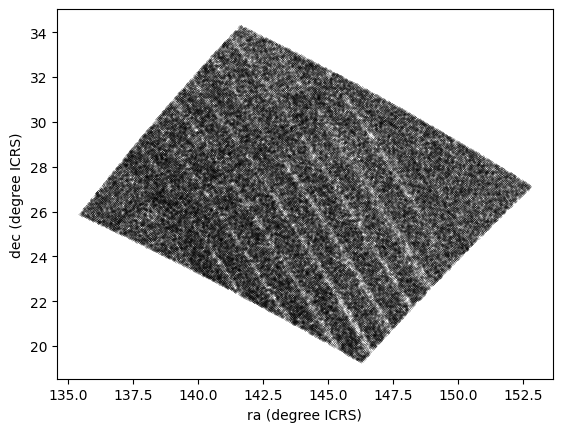

In [10]:
%matplotlib inline

import matplotlib.pyplot as plt

x = polygon_results['ra']
y = polygon_results['dec']
plt.plot(x, y, 'ko', markersize=0.1)

plt.xlabel('ra (degree ICRS)')
plt.ylabel('dec (degree ICRS)')

In [11]:
distance = 8 * u.kpc
radial_velocity= 0 * u.km/u.s

skycoord = SkyCoord(
    ra=polygon_results['ra'],
    dec=polygon_results['dec'],
    pm_ra_cosdec=polygon_results['pmra'],
    pm_dec=polygon_results['pmdec'],
    distance=distance,
    radial_velocity=radial_velocity,
)
skycoord

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, kpc)
    [(142.48301936, 21.75771617, 8.), (142.25452941, 22.47616817, 8.),
     (142.64528557, 22.16693225, 8.), ..., (143.41554585, 21.19860268, 8.),
     (143.69087392, 21.11356247, 8.), (143.77026813, 21.38317628, 8.)]
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    [( -2.51683847,   2.9418131 , 0.), (  2.66270201, -12.1659844 , 0.),
     ( 18.30674739,  -7.95065962, 0.), ...,
     (-18.80278676,  -0.63556945, 0.), ( -6.82888101, -12.53223687, 0.),
     ( -5.90072495,   1.97640029, 0.)]>

In [12]:
transformed = skycoord.transform_to(gd1_frame)
transformed

<SkyCoord (GD1Koposov10): (phi1, phi2, distance) in (deg, deg, kpc)
    [(-54.97562251, -3.65934904, 8.), (-54.4982471 , -3.08152388, 8.),
     (-54.55163387, -3.55422922, 8.), ..., (-54.94894646, -4.69129505, 8.),
     (-54.87334917, -4.95108083, 8.), (-54.6083886 , -4.85901398, 8.)]
 (pm_phi1_cosphi2, pm_phi2, radial_velocity) in (mas / yr, mas / yr, km / s)
    [(  1.02504998,   3.7333648 , -8.90042666e-09),
     ( -8.59069569,  -9.01671258,  2.41133319e-08),
     (  3.70928841, -19.6109961 ,  4.41214262e-08), ...,
     (-11.15848485,  15.14717644, -3.03262813e-08),
     (-14.19483497,  -1.48230794,  7.45324099e-09),
     ( -1.72375714,   5.97941254, -1.27358082e-08)]>

Text(0, 0.5, 'phi2 (degree GD1)')

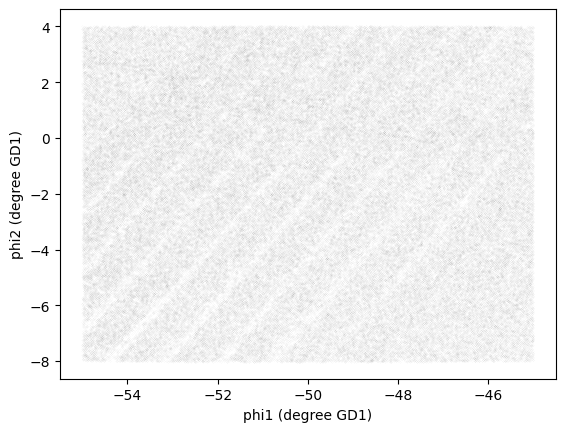

In [13]:
from gala.coordinates import reflex_correct

skycoord_gd1 = reflex_correct(transformed)

x = skycoord_gd1.phi1
y = skycoord_gd1.phi2
plt.plot(x, y, 'ko', markersize=0.1, alpha=0.1)

plt.xlabel('phi1 (degree GD1)')
plt.ylabel('phi2 (degree GD1)')

In [17]:
import xarray as xr
import astropy_xarray


def make_gd1_dataset(table) -> xr.Dataset:
    """Transform coordinates from ICRS table to GD-1 dataset.

    table: Astropy Table

    returns: xarray Dataset
    """
    #Create a SkyCoord object with the coordinates and proper motions
    # in the input table
    skycoord = SkyCoord(
        ra=table['ra'],
        dec=table['dec'],
        pm_ra_cosdec=table['pmra'],
        pm_dec=table['pmdec'],
        distance=8*u.kpc,
        radial_velocity=0*u.km/u.s,
    )

    # Define the GD-1 reference frame
    gd1_frame = GD1Koposov10()

    # Transform input coordinates to the GD-1 reference frame
    transformed = skycoord.transform_to(gd1_frame)

    # Correct GD-1 coordinates for solar system motion around galactic center
    skycoord_gd1 = reflex_correct(transformed)

    #Add GD-1 reference frame columns for coordinates and proper motions
    table['phi1'] = skycoord_gd1.phi1
    table['phi2'] = skycoord_gd1.phi2
    table['pm_phi1'] = skycoord_gd1.pm_phi1_cosphi2
    table['pm_phi2'] = skycoord_gd1.pm_phi2

    # Create DataFrame
    return xr.Dataset(
        data_vars={
            name: xr.DataArray(
                col,
                dims=['source_id'],
                attrs={
                    'description': col.description,
                    'units': col.unit
                }
            ) for name, col in polygon_results.items()
        }
    ).astropy.quantify()


In [18]:
gd1_ds = make_gd1_dataset(polygon_results)
gd1_ds

<xarray.Dataset> Size: 11MB
Dimensions:    (source_id: 140339)
Coordinates:
  * source_id  (source_id) int64 1MB 637987125186749568 ... 634922507107068672
Data variables:
    ra         (source_id) float64 1MB [°] 142.5 142.3 142.6 ... 143.7 143.8
    dec        (source_id) float64 1MB [°] 21.76 22.48 22.17 ... 21.11 21.38
    pmra       (source_id) float64 1MB [mas yr⁻¹] -2.517 2.663 ... -6.829 -5.901
    pmdec      (source_id) float64 1MB [mas yr⁻¹] 2.942 -12.17 ... -12.53 1.976
    parallax   (source_id) float64 1MB [mas] -0.2573 0.4227 ... 0.5853 0.9562
    phi1       (source_id) float64 1MB [°] -54.98 -54.5 -54.55 ... -54.87 -54.61
    phi2       (source_id) float64 1MB [°] -3.659 -3.082 ... -4.951 -4.859
    pm_phi1    (source_id) float64 1MB [mas yr⁻¹] 6.43 -3.169 ... -8.786 3.694
    pm_phi2    (source_id) float64 1MB [mas yr⁻¹] 6.518 -6.207 ... 1.252 8.719

In [19]:
import zarr.storage as zs

with zs.ZipStore("gd1.zip", mode='w') as store:
    saved = gd1_ds.astropy.dequantify().to_zarr(
        store,
        mode="w"
    )
saved

/home/callan/.pyenv/versions/3.12.1/lib/python3.12/zipfile/__init__.py:1590: UserWarning: Duplicate name: 'zarr.json'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/home/callan/.pyenv/versions/3.12.1/lib/python3.12/zipfile/__init__.py:1590: UserWarning: Duplicate name: 'pm_phi2/zarr.json'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/home/callan/.pyenv/versions/3.12.1/lib/python3.12/zipfile/__init__.py:1590: UserWarning: Duplicate name: 'pm_phi1/zarr.json'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/home/callan/.pyenv/versions/3.12.1/lib/python3.12/zipfile/__init__.py:1590: UserWarning: Duplicate name: 'dec/zarr.json'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/home/callan/.pyenv/versions/3.12.1/lib/python3.12/zipfile/__init__.py:1590: UserWarning: Duplicate name: 'phi2/zarr.json'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/home/callan/.pyenv/versions/3.12.1/lib/python3.12/zipfile/__init__.py:1590: Use

In [1]:
import xarray as xr
import zarr.storage as zs

with zs.ZipStore("gd1.zip", mode='r') as store:
    loaded = xr.open_dataset(store, engine="zarr")

gd1_ds = loaded
gd1_ds

<xarray.Dataset> Size: 11MB
Dimensions:    (source_id: 140339)
Coordinates:
  * source_id  (source_id) int64 1MB 637987125186749568 ... 634922507107068672
Data variables:
    pm_phi2    (source_id) float64 1MB ...
    pm_phi1    (source_id) float64 1MB ...
    dec        (source_id) float64 1MB ...
    phi2       (source_id) float64 1MB ...
    ra         (source_id) float64 1MB ...
    pmdec      (source_id) float64 1MB ...
    phi1       (source_id) float64 1MB ...
    parallax   (source_id) float64 1MB ...
    pmra       (source_id) float64 1MB ...

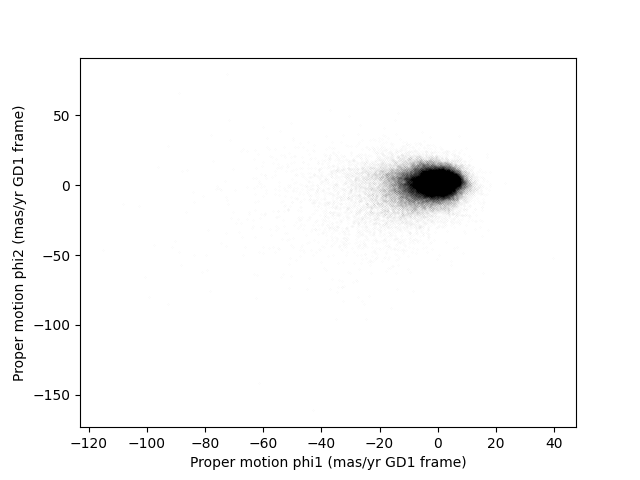

/home/callan/Code/astropy-xarray/.venv/lib/python3.12/site-packages/ipympl/backend_nbagg.py:285: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.manager.handle_json(content)
/home/callan/Code/astropy-xarray/.venv/lib/python3.12/site-packages/ipympl/backend_nbagg.py:285: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.manager.handle_json(content)
/home/callan/Code/astropy-xarray/.venv/lib/python3.12/site-packages/ipympl/backend_nbagg.py:285: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.manager.handle_json(content)
/home/callan/Code/astropy-xarray/.venv/lib/python3.12/site-packages/ipympl/backend_nbagg.py:285: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.manager.handle_json(content)
/home/callan/Code/astropy-xarray/.venv/lib/python3.12/site-packages/ipympl/backend_nbagg.py:285: UserWarning: Creating legend wi

In [2]:
%matplotlib widget

import matplotlib.pyplot as plt

plt.plot(
    gd1_ds['pm_phi1'],
    gd1_ds['pm_phi2'],
    'ko',
    markersize=0.1,
    alpha=0.1
)
plt.xlabel('Proper motion phi1 (mas/yr GD1 frame)')
plt.ylabel('Proper motion phi2 (mas/yr GD1 frame)')
plt.show()


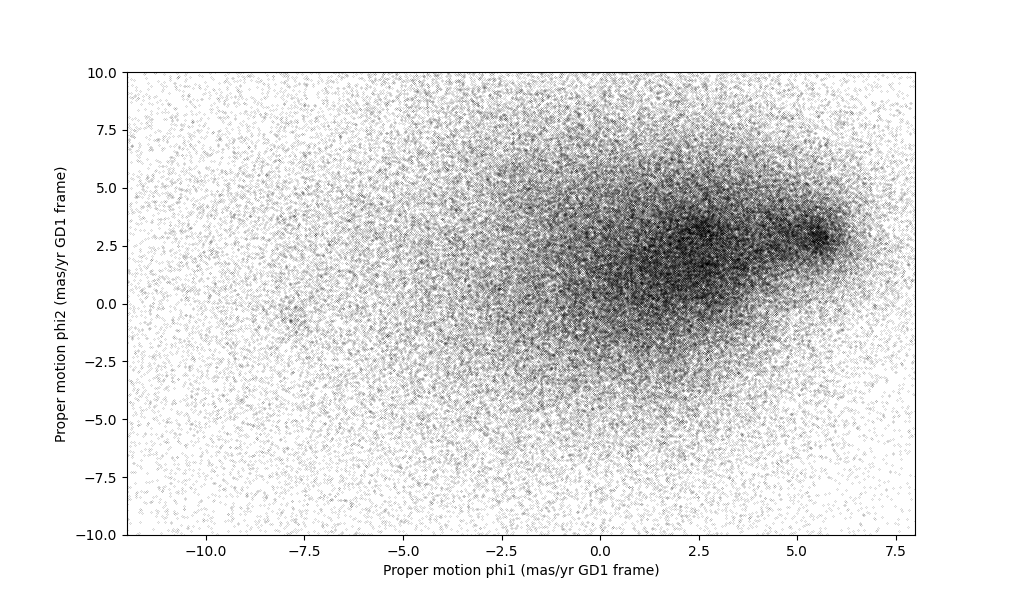

In [5]:
x = gd1_ds['pm_phi1']
y = gd1_ds['pm_phi2']
plt.plot(x, y, 'ko', markersize=0.1, alpha=0.3)

plt.xlabel('Proper motion phi1 (mas/yr GD1 frame)')
plt.ylabel('Proper motion phi2 (mas/yr GD1 frame)')

plt.xlim(-12, 8)
plt.ylim(-10, 10)
plt.show()

/tmp/ipykernel_1193529/3450769922.py:10: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  (gd1_ds.dims['source_id'],)
/home/callan/Code/astropy-xarray/.venv/lib/python3.12/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


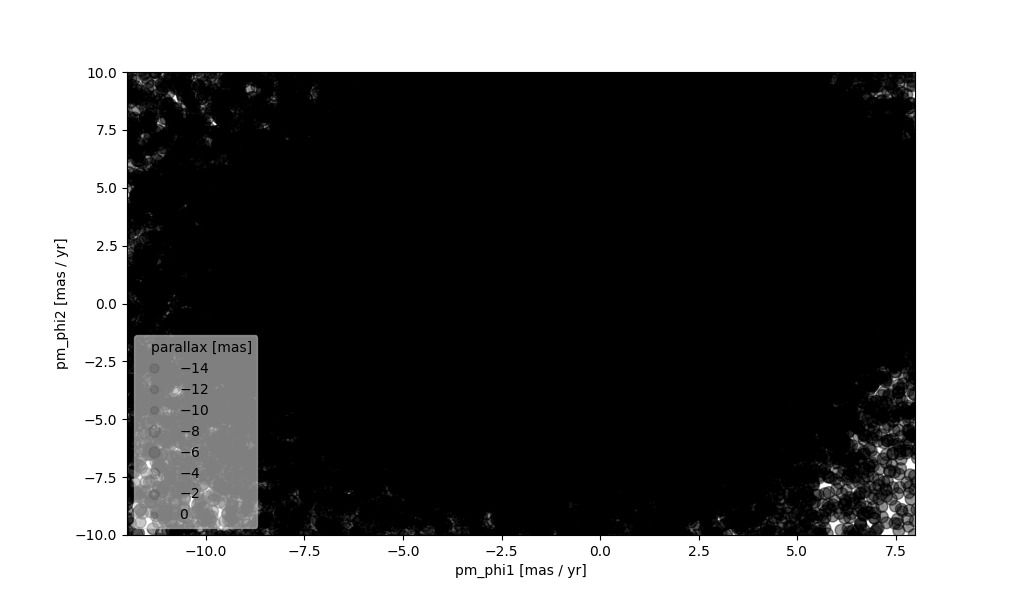

/tmp/ipykernel_1193529/1895951262.py:10: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  (gd1_ds.dims['source_id'],)
/home/callan/Code/astropy-xarray/.venv/lib/python3.12/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


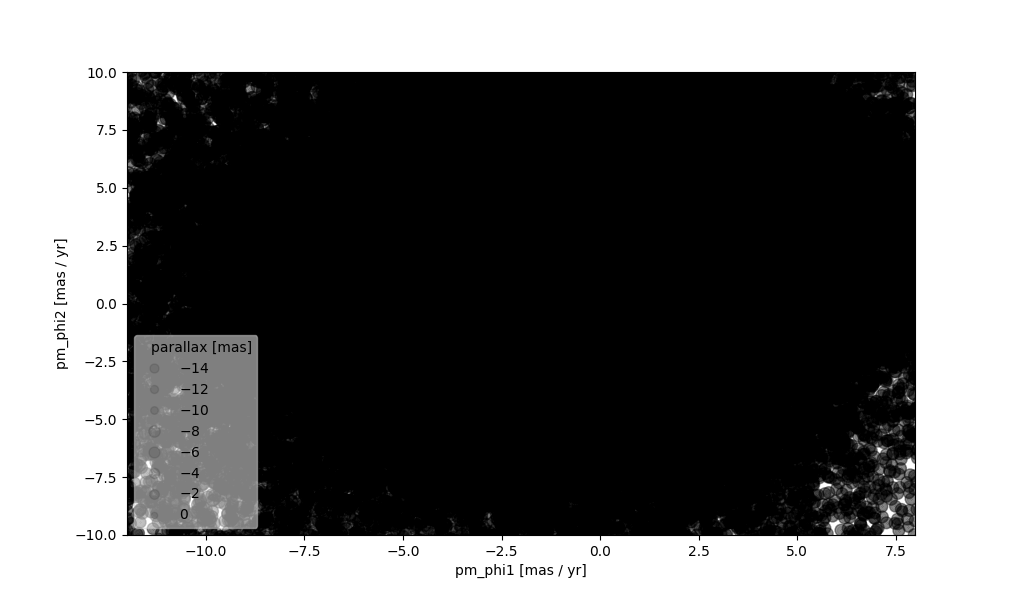

In [12]:
%matplotlib widget

import astropy_xarray
import numpy as np

plot_gd1 = gd1_ds.assign_coords(
    coords=dict(markersize=(
        'source_id', np.broadcast_to(
            1,
            (gd1_ds.dims['source_id'],)
        )
    ))
)

ax = plt.subplot(1,1,1)
plot_gd1.astropy.dequantify(
    format="unicode"
).plot.scatter(
    x='pm_phi1', y='pm_phi2',
    alpha=0.1, color='k', marker='o', ax=ax
)
plt.show()

In [176]:
phi2_min = -1.0 * u.degree
phi2_max = 1.0 * u.degree

phi2_mask = (phi2_min < gd1_ds['phi2']) & (gd1_ds['phi2'] < phi2_max)
print(phi2_mask.sum())

centerline_ds = gd1_ds.where(phi2_mask)
centerline_ds

<xarray.DataArray 'phi2' ()> Size: 8B
array(25084)


<xarray.Dataset> Size: 11MB
Dimensions:    (source_id: 140339)
Coordinates:
  * source_id  (source_id) int64 1MB 637987125186749568 ... 634922507107068672
Data variables:
    ra         (source_id) float64 1MB [°] nan nan nan nan ... nan nan nan nan
    dec        (source_id) float64 1MB [°] nan nan nan nan ... nan nan nan nan
    pmra       (source_id) float64 1MB [mas yr⁻¹] nan nan nan ... nan nan nan
    pmdec      (source_id) float64 1MB [mas yr⁻¹] nan nan nan ... nan nan nan
    parallax   (source_id) float64 1MB [mas] nan nan nan nan ... nan nan nan nan
    phi1       (source_id) float64 1MB [°] nan nan nan nan ... nan nan nan nan
    phi2       (source_id) float64 1MB [°] nan nan nan nan ... nan nan nan nan
    pm_phi1    (source_id) float64 1MB [mas yr⁻¹] nan nan nan ... nan nan nan
    pm_phi2    (source_id) float64 1MB [mas yr⁻¹] nan nan nan ... nan nan nan

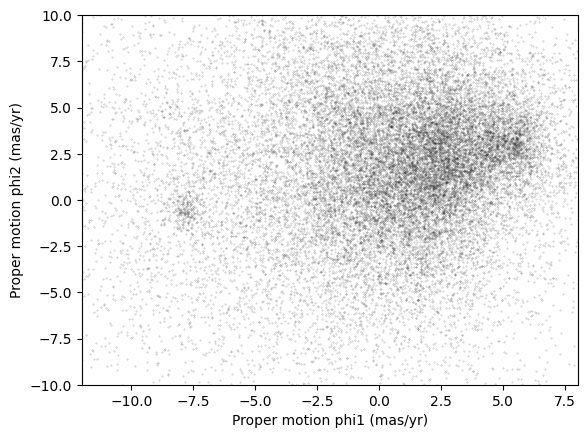

In [148]:
def plot_proper_motion(df):
    """Plot proper motion.

    df: DataFrame with `pm_phi1` and `pm_phi2`
    """
    x = df['pm_phi1']
    y = df['pm_phi2']
    plt.plot(x, y, 'ko', markersize=0.3, alpha=0.3)

    plt.xlabel('Proper motion phi1 (mas/yr)')
    plt.ylabel('Proper motion phi2 (mas/yr)')

    plt.xlim(-12, 8)
    plt.ylim(-10, 10)

plot_proper_motion(centerline_ds)